# Data 300: Statistical and Machine Learning (Fall 2025)


# Homework #10: Model Selection and Regularization

<font color='red'>**Due Date and Time:** 10:30am on Friday, 10/31/2025 </font>
---
Enter your name in the markdown cell below.

# Name: Thao

In [1]:
## RUN THIS CELL TO GET THE RIGHT FORMATTING
import requests
from IPython.core.display import HTML
styles = requests.get("https://raw.githubusercontent.com/Harvard-IACS/2018-CS109A/master/content/styles/cs109.css").text
HTML(styles)

# Tasks

- Review pages 218-225 in the Course Notes.
- Complete the **(1) Feature Selection II - Selecting for Model Accuracy** chapter of the **Dimensionality Reduction in Python** course, and the **(2) Classification and Regression Trees** and **(3) The Bias-Variance Tradeoff** chapters of the **Machine Learning with Tree-Based Models in Python** course on DataCamp.
- E-mail me your completed Jupyter notebook.

## Main Goals

The purpose of this lab/homework is to:

- Learn how to create a **feature matrix** (also called a **design matrix**) for linear regression in *scikit-learn*.  
- Practice using **Lasso and Ridge regression**.  
- Apply **cross-validation (CV)** to **compare** the performance of three alternative model specifications.


## Case Study: Deregulation of the Intrastate Trucking Industry

This case study examines how **deregulation** affected the prices charged for **intrastate motor transport services** (trucking) in Florida during the early 1980s.

### Background
Before July 1, 1980, Florida’s **Public Service Commission** determined official rate schedules for trucking services, and individual carriers were not permitted to deviate from these approved rates. On that date, Florida became the first state to remove such regulatory constraints—allowing carriers to set their own prices for shipments within the state.

### Objectives
The regression analysis in this case study has two primary goals:
1. **Assess the impact of deregulation** on the prices charged for motor transport service within Florida.
2. **Develop a model of the supply price** to help predict future trucking prices.

## The Trucking Dataset

The **Trucking.csv** dataset represents a subset of a larger population of over **27,000 shipments** made before and after deregulation. It contains **134 observations** of shipments originating from either **Miami** or **Jacksonville** for one particular carrier.

- **Observations (rows):** 134 rows 
- **Variables (columns):** 8  

### Column Descriptions
- **PricePTM** – Price charged per ton-mile (the cost to ship one ton of freight one mile) in 1980 dollars.
- **Distance** – Distance of the haul (in hundreds of miles)  
- **Weight** – Shipment weight in **1,000 pounds (lbs)**  
- **PCTLoad** – Percentage of the truck’s total capacity used by the shipment  
- **Origin** – Origin city (*Miami* or *Jacksonville*)  
- **Market** – Market size classification of the destination, coded as either **Large** or **Small**  
- **Dereg** – Indicator for whether the shipment occurred after industry deregulation (*Yes*, *No*)  

## Load and Explore the Trucking Dataset

In the data directory, you will find the csv file for the trucking dataset: `Trucking.csv`.

Run the two code cells below, which does the following:
- Imports the libraries that we will be using in this notebook.
- Sets `datadir = "regData"` and uses the `os.path.join(.)` function to create a full path to the data.
- Reads in the file `Trucking.csv` and assigned it to the data frame `trucking_df`.<br>

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

In [3]:
datadir = "hw10Data"
trucking_path = os.path.join(datadir, "Trucking.csv")
trucking_df = pd.read_csv(trucking_path)

Recall that by default, Pandas will **infer the data type** of each column when we load a dataset.  It’s always a good idea to check these guesses to make sure they match what we expect (numeric vs. categorical, etc.).

**Run the code cell below to display the inferred data types for each column.**

In [4]:
print(trucking_df.dtypes)

PricePTM      int64
Distance    float64
Weight      float64
PCTLoad     float64
Origin       object
Market       object
Dereg        object
dtype: object


From the data types above, we see that our categorical predictors are stored as `object`.   As before, we will convert these to **categorical** variables so they can be handled properly later on (for modeling).  

**Run the code cell below to convert the object columns into categorical variables.**

In [5]:
# Convert categorical features stored as object → category
categorical_cols = ["Origin", "Market", "Dereg"]
trucking_df[categorical_cols] = trucking_df[categorical_cols].astype("category")

print(trucking_df.dtypes)

PricePTM       int64
Distance     float64
Weight       float64
PCTLoad      float64
Origin      category
Market      category
Dereg       category
dtype: object


**Run the code cell below to verify there are no missing values.**

In [6]:
# Count missing values in each column
trucking_df.isnull().sum()

PricePTM    0
Distance    0
Weight      0
PCTLoad     0
Origin      0
Market      0
Dereg       0
dtype: int64

## Considering a Log Transformation of Price

Before building our regression model, we should check whether **Price per Ton-Mile (PricePTM)** is suitable to model directly or whether a **log transformation** might be more appropriate.

Economic and cost data often have **right-skewed distributions** — a few very high values can dominate the scale.  
Taking the **natural log of PricePTM** can:
- Make the distribution more symmetric (closer to normal),
- Stabilize variance (reduce heteroscedasticity),
- Linearize multiplicative relationships, and
- Allow model coefficients to be interpreted in **percentage terms**.

We'll inspect the distribution of `PricePTM` and its logarithm to decide whether modeling **log(PricePTM)** is more appropriate.

**Run the code cell below to create side-by-side histograms of `PricePTM` and `log(PricePTM)`.**


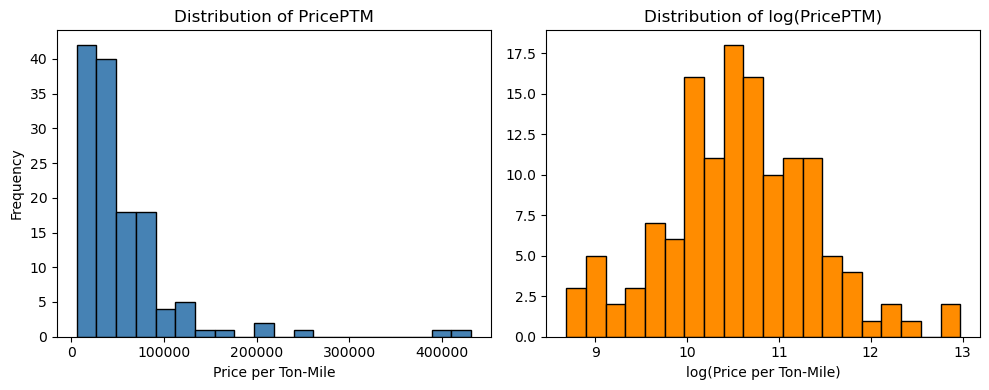

In [7]:
## Visualizing the distribution of PricePTM vs. log(PricePTM)

# Compute log of PricePTM (add a small constant to avoid log(0) if needed)
log_price = np.log(trucking_df["PricePTM"])

# Create side-by-side histograms
plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.hist(trucking_df["PricePTM"], bins=20, color="steelblue", edgecolor="black")
plt.title("Distribution of PricePTM")
plt.xlabel("Price per Ton-Mile")
plt.ylabel("Frequency")

plt.subplot(1, 2, 2)
plt.hist(log_price, bins=20, color="darkorange", edgecolor="black")
plt.title("Distribution of log(PricePTM)")
plt.xlabel("log(Price per Ton-Mile)")

plt.tight_layout()
plt.show()

## Why Use log(PricePTM) as the Response Variable?

The histogram on the left shows that **Price per Ton-Mile (PricePTM)** is heavily **right-skewed** — most shipments have low prices, but a few are much higher.  

The histogram on the right shows **log(PricePTM)**, which appears **much more symmetric and approximately bell-shaped**. 

Taking the natural log compresses large values and expands smaller ones, producing a distribution that better satisfies the normality and equal variance assumptions.

✅ **Conclusion:**  
Because the log transformation stabilizes variance, reduces skewness, and often linearizes relationships, it is more appropriate to model `log(PricePTM)` as the response variable instead of `PricePTM` itself.


<div class="exercise"><b>Exercise 1: Plot the Lasso Regression Coefficient Path</b></div> 

Now that we’ve decided to model the **natural log of price per ton-mile** (`log(PricePTM)`), we’ll apply **Lasso regression** using *all available predictors*.

Your task in this exercise is to write code to create a figure of the *lasso coefficient paths:*
    
### In particular, your code should:
1. **Define the predictors and response:**  
   Use all shipment characteristics (`Distance`, `Weight`, `PCTLoad`, `Origin`, `Market`, and `Dereg`) to predict **`log(PricePTM)`**.

2. **Encode categorical variables:**  
   Convert the categorical variables into numerical dummy variables using one-hot encoding.

3. **Standardizes predictors:**  
   Center and scale all variables so they’re on the same scale (using `StandardScalar()`)

4. **Fit multiple Lasso models:**  
   The model should be fit for a wide range of penalty strengths (`np.logspace(-3, 2, 100)`)  

5. **Plot coefficient paths:**  
   Display how each coefficient changes as λ varies.  
---

**In the code cell below, write code to accomplish this task. Your graph should match that of Figure 1 below.**

<p align="center"><b>Figure 1. Lasso Coefficient Paths</b></p>

<p align="center">
  <img src="hw10Data/fig1.png" alt="Figure 1: Lasso Coefficient Paths" width="600"/>
</p>

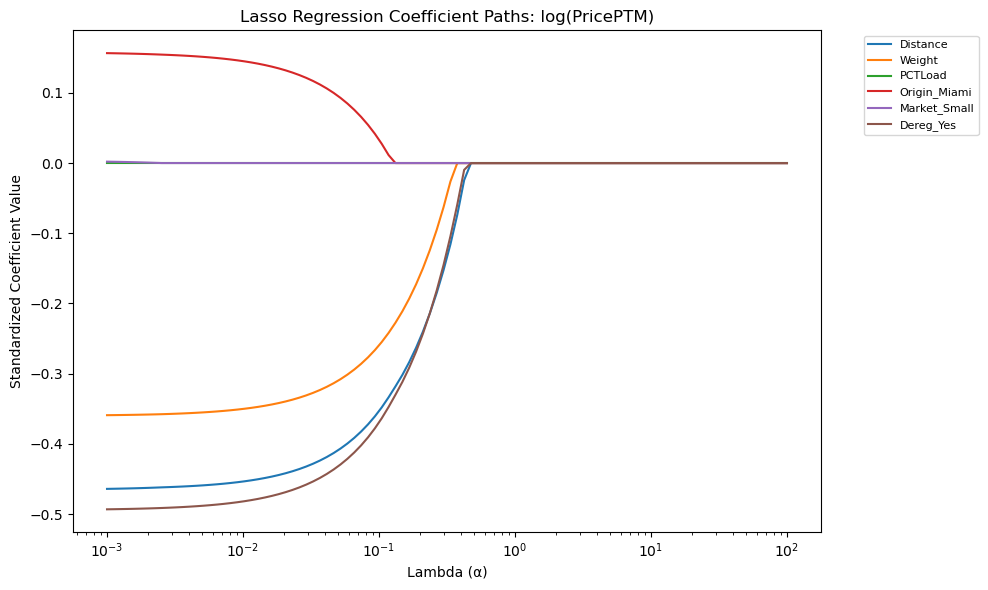

In [8]:
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Lasso
import numpy as np

X_raw = trucking_df[["Distance", "Weight", "PCTLoad", "Origin", "Market", "Dereg"]]
y = np.log(trucking_df["PricePTM"])

X = pd.get_dummies(X_raw, drop_first=True)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

alphas = np.logspace(-3, 2, 100) 
coefs = []
for alpha in alphas:
 lasso = Lasso(alpha=alpha, max_iter=10000)
 lasso.fit(X_scaled, y)
 coefs.append(lasso.coef_)
coefs = np.array(coefs)

plt.figure(figsize=(10,6))
plt.plot(alphas, coefs)
plt.xscale("log")
plt.xlabel("Lambda (α)")
plt.ylabel("Standardized Coefficient Value")
plt.title("Lasso Regression Coefficient Paths: log(PricePTM)")
plt.legend(X.columns, bbox_to_anchor=(1.05, 1), loc="upper left", fontsize=8)
plt.tight_layout()
plt.show()

<div class="exercise"><b>Exercise 2: Interpreting the Coefficient Paths</b></div>

In the markdown cell below, answer the following multiple choice questions—no explanations are necessary.  

1. At small values of λ (on the left side of the plot), which predictors appear to be most influential in explaining `log(PricePTM)`?  
   - A) Distance and Weight have the largest coefficient magnitudes.  
   - B) All coefficients are zero.  
   - C) Categorical variables Origin and Dereg dominate the model.  
   - D) No variables are significant when λ is small.  

---

2. As λ (alpha) increases toward the right side of the plot, which of the following best describes what happens to the coefficients?  
   - A) All coefficients gradually increase in magnitude.  
   - B) Coefficients shrink toward zero, and some become exactly zero, simplifying the model.  
   - C) Coefficients change direction and become negative.  
   - D) The model adds more predictors as λ increases.  

1 A 
2 B 

<div class="exercise"><b>Exercise 3: Perform Hyperparameter Tuning to Find Optimal λ</b></div>

Your task in this exercise is to use **cross-validation** to automatically choose the best value of λ (alpha) for our Lasso regression model. Recall that this process is called **hyperparameter tuning**.

---

### In particular, your code should:

**1) Define the range of λ (alpha) values**
- Because Lasso tends to respond more strongly to changes in λ, use  `np.logspace(-3, 2, 100)`

**2) Set up 5-fold cross-validation**


**3) Use `GridSearchCV` to perform hyperparameter tuning**


**4) Fit the grid search**


**5) Retrieve and print the best λ value**

**6) Plot cross-validation error vs. λ**

**7) Print the optimal value of λ and theh values of the optimal coefficients in order of magnitude**

---

<span style="color:red"><b>In the code cell below, write code to accomplish this task. Your graph and coefficients should match that below.</b></span>

<p align="center"><b>Figure 2: Lasso Regression: CV Error vs. Lambda — log(PricePTM)</b></p>

<p align="center">
  <img src="hw10Data/Fig2.png" alt="Figure 2: Lasso Regression: CV Error vs. Lambda — log(PricePTM)" width="700"/>
</p>


Best lambda (alpha): 0.0010


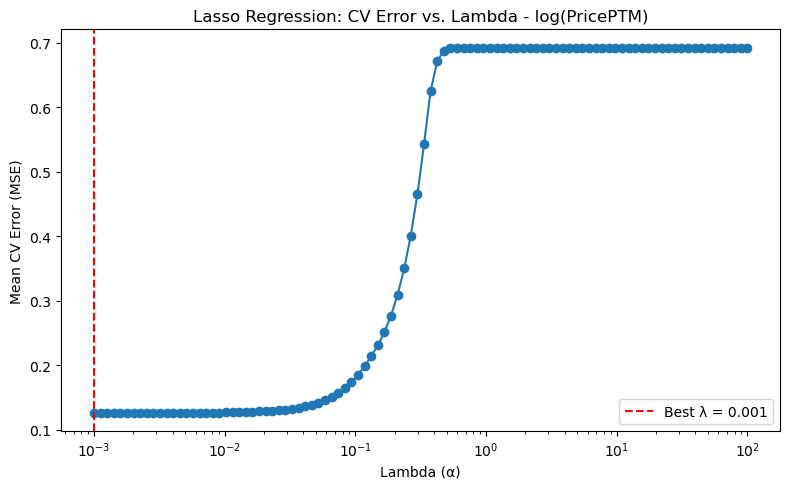

       Variable  Coefficient
5     Dereg_Yes    -0.493182
0      Distance    -0.464072
1        Weight    -0.359112
3  Origin_Miami     0.156562
4  Market_Small     0.002010
2       PCTLoad    -0.000000


In [9]:
from sklearn.model_selection import KFold, GridSearchCV
alphas = np.logspace(-3, 2, 100)

cv = KFold(n_splits=5, shuffle=True, random_state=42)
gs = GridSearchCV(
 estimator=Lasso(max_iter=10000),
 param_grid={"alpha": alphas},
 scoring="neg_mean_squared_error",
 cv=cv,
 return_train_score=True,
)

gs.fit(X_scaled, y)

best_alpha = gs.best_params_["alpha"]
print(f"Best lambda (alpha): {best_alpha:.4f}")
mean_cv_mse = -gs.cv_results_["mean_test_score"] 

plt.figure(figsize=(8,5))
plt.semilogx(alphas, mean_cv_mse, marker="o")
plt.axvline(best_alpha, linestyle="--", color="red", label=f"Best λ = {best_alpha:.3f}")
plt.xlabel("Lambda (α)")
plt.ylabel("Mean CV Error (MSE)")
plt.title("Lasso Regression: CV Error vs. Lambda - log(PricePTM)")
plt.legend()
plt.tight_layout()
plt.show()
best_lasso = gs.best_estimator_
all_coefs = pd.Series(best_lasso.coef_, index=X.columns)


all_coefs_df = all_coefs.reset_index()
all_coefs_df.columns = ["Variable", "Coefficient"]
all_coefs_df = all_coefs_df.reindex(all_coefs_df["Coefficient"].abs().sort_values(ascending=False).index)
print(all_coefs_df)

<div class="exercise"><b>Exercise 4: Interpreting the Lasso CV and Coefficient Results</b></div>

In the markdown cell below, answer the following multiple choice questions—no explanations are necessary.  

1. Based on the cross-validation (CV) plot of mean squared error (MSE) versus λ, which of the following best describes the model’s performance?  
   - A) The model’s error decreases as λ increases indefinitely.  
   - B) The model achieves its lowest CV error at approximately λ = 0.001, suggesting mild regularization gives the best balance between bias and variance.  
   - C) The model performs best with very strong regularization (λ ≈ 100).  
   - D) The model performs best when λ = 0 (no regularization).  

---

2. At the optimal λ selected by CV, which predictors have the **largest coefficient magnitudes** in the fitted Lasso model?  
   - A) Dereg_Yes and Distance  
   - B) Origin_Miami and Market_Small  
   - C) PCTLoad and Market_Small  
   - D) All coefficients are near zero and none stand out  

---

3. As λ increases beyond the optimal value (moving right on the CV plot), which of the following best describes what happens to the model coefficients?  
   - A) Coefficients increase in size and overfit the data.  
   - B) Coefficients shrink toward zero, with weaker predictors dropping out of the model first.  
   - C) Coefficients remain constant because λ does not affect them.  
   - D) The number of nonzero coefficients increases.  


1 B 
2 A 
3 B

## Model A

The results of our Lasso regression suggest that we can drop the predictors `Market_Small` and `PCTLoad` as their coefficients are essentially zero. By removing these weaker variables, we create a more parsimonious model, which we will call **Model A**, that focuses on the strongest predictors.

**Model A:** `Distance`, `Weight`, `Dereg`, and `Origin`

This simplified model retains the key economic relationships while reducing model complexity. It should provide similar predictive performance with improved interpretability.

---

We will now apply **5-fold cross-validation (CV)** to **Model A** using **standard linear regression** (ordinary least squares).

Since Model A contains only a few carefully chosen predictors, switching from Lasso to OLS is a good idea:
- The smaller model reduces the risk of overfitting, so regularization is no longer necessary.  
- OLS provides **unbiased and easily interpretable coefficients**, which is ideal for understanding how distance, weight, and deregulation affect price per ton-mile.

---

To make our cross-validation results more reliable, we’ll use the **`KFold()`** class along with `cross_val_score()`.  
`KFold()` explicitly controls how the data are split into folds — here we use 5 folds, and we set `shuffle=True` (with a random seed) to ensure that each fold is a **representative mix** of the data. This helps avoid biased or unstable folds that can occur if the data are ordered in some way.

**Run the code cell below** to perform **5-fold CV** on **Model A** using `KFold()` and evaluate its predictive performance.


In [10]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import KFold, cross_val_score

# Define features (and encode dummies) and target
# 1) Define features and target (start from the four core predictors)
X_raw = trucking_df[["Distance", "Weight", "Origin", "Dereg"]].copy()
y = np.log(trucking_df["PricePTM"])

# One-hot encode categorical variables (drop_first avoids the dummy trap)
X_modelA = pd.get_dummies(X_raw, drop_first=True)

model = LinearRegression()
kf = KFold(n_splits=5, shuffle=True, random_state=42)

# 5-fold cross-validation (scoring by R^2)
cv_scores = cross_val_score(model, X_modelA, y, cv=kf, scoring='r2')

print("Cross-validation R^2 scores:", cv_scores)
print("Mean R^2:", np.mean(cv_scores))
print("Standard deviation:", np.std(cv_scores))

Cross-validation R^2 scores: [0.74862857 0.85234667 0.90052449 0.76653064 0.70450099]
Mean R^2: 0.7945062701780626
Standard deviation: 0.07151744363019419


### Interpreting the Cross-Validation Results

The 5-fold cross-validation $R^2$ scores are:

$$
[0.749,\ 0.852,\ 0.901,\ 0.767,\ 0.705]
$$

with a **mean $R^2 = 0.795$** and **standard deviation = 0.072**.

These results indicate that **Model A performs consistently well across all folds**, explaining about **80% of the variation** in `log(PricePTM)` on average.  The small standard deviation suggests **stable predictive performance**, confirming that the model generalizes well and that shuffling the folds eliminated the instability we saw earlier.


## Extending Model A with Curvature and Interaction Effects

**Model A** uses four core predictors — `Distance`, `Weight`, `Dereg`, and `Origin`.  
This captures the key relationships but assumes all effects are **linear** and **independent**.

To allow more realistic patterns, we now add a small set of **quadratic** and **interaction** terms that are economically and statistically sensible:

- **`Distance²` (curvature):** Per–ton-mile cost may change nonlinearly with distance (e.g., diminishing marginal cost on longer hauls).
- **`Weight × Distance` (economies of density):** Heavier loads may achieve stronger cost reductions on longer trips.
- **`Dereg × Distance` (policy heterogeneity):** The effect of deregulation may differ for short vs. long hauls.

These additions let us explore nonlinear and joint effects **without** exploding the feature space. We will again rely on **Lasso regularization** to identify which added features materially improve predictive performance.

> **Best practice:** One-hot encode categorical variables **before** creating interactions.

**In the next code cell, you will:**
1. Form the feature matrix `X` and response `y` (`log(PricePTM)`).
2. **Encode** the categorical variables (`Origin`, `Dereg`) with one-hot encoding.
3. **Print** the resulting column names to verify the dummies and new features.

**Run the code cell below.**

In [11]:
# 1) Define features and target (start from the four core predictors)
X_raw = trucking_df[["Distance", "Weight", "Origin", "Dereg"]].copy()
y = np.log(trucking_df["PricePTM"])  # Natural log of price per ton-mile

# 2) One-hot encode categorical variables (drop_first avoids the dummy trap)
X = pd.get_dummies(X_raw, drop_first=True)

# 3) Print the names of columns (so we can see how the dummy variables were encoded)
print(X.columns.tolist())

['Distance', 'Weight', 'Origin_Miami', 'Dereg_Yes']


### Interpreting the Encoded Variable Names

The output above shows the column names created after applying one-hot encoding with `pd.get_dummies()`:

- The numeric predictors (`Distance`, `Weight`) remain unchanged.  
- Each categorical variable generates a new **dummy column**:
  - `Origin_Miami` equals 1 for shipments originating in Miami and 0 otherwise.
  - `Dereg_Yes` equals 1 for deregulated shipments and 0 for regulated ones.
- Because `drop_first=True` was used, the reference (baseline) categories — such as *Jacksonville origins* and *non-deregulated shipments* — are automatically omitted to avoid multicollinearity.


## Creating New Features and Plotting Coefficient Paths

In the code below, we **extend our feature matrix `X`** by adding new columns for curvature and interaction effects.  
Each line of code creates a new variable directly in `X`:

- `X["Distance_sq"]` adds a quadratic term for distance.  
- `X["Weight_x_Distance"]` multiplies weight and distance to capture their joint effect.  
- `X["Dereg_x_Distance"]` uses the dummy variable `Dereg_Yes` to create an interaction between deregulation and distance.

After creating these new columns, we:
1. **Standardize** all predictors so they are on comparable scales.  
2. **Fit Lasso models** across a range of penalty values (`λ` or `alpha`).  
3. **Plot the coefficient paths**, showing how each variable’s importance changes as regularization strength increases.

**Please run the code cell below.**

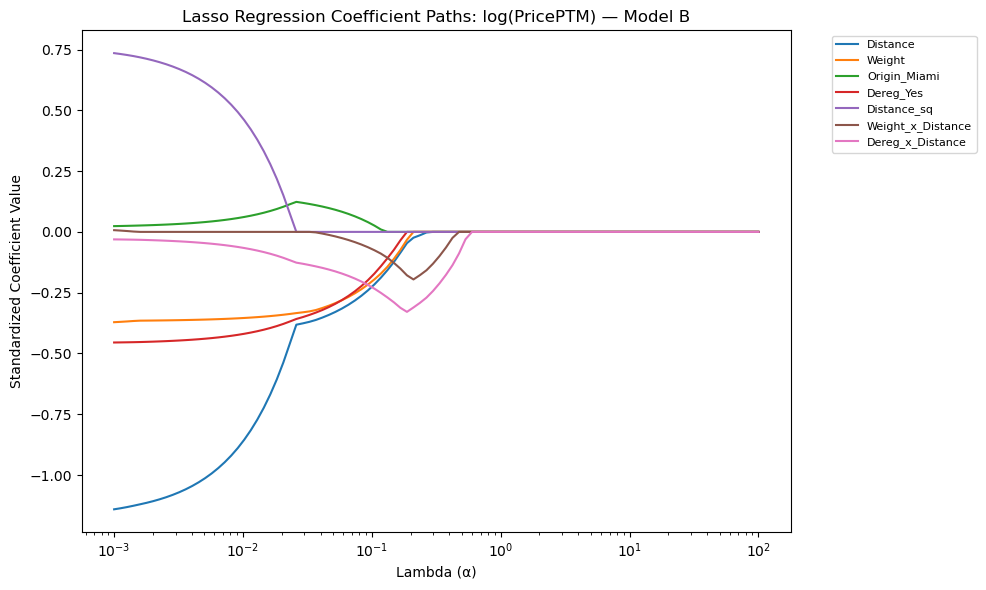

In [12]:
## Lasso Regression: Coefficient Paths for the Trucking Dataset (with targeted nonlinearities)

# 1) --- Add targeted quadratic & interaction terms ---
# Curvature in distance
X["Distance_sq"] = X["Distance"] ** 2

# Economies of density: weight × distance
X["Weight_x_Distance"] = X["Weight"] * X["Distance"]

# Policy interaction: deregulation × distance
X["Dereg_x_Distance"] = X["Dereg_Yes"] * X["Distance"]

# 2) Standardize predictors
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 3) Fit Lasso models for a range of lambda (alpha) values
alphas = np.logspace(-3, 2, 100)  # λ from 0.001 to 100
coefs = []

for alpha in alphas:
    lasso = Lasso(alpha=alpha, max_iter=10000)
    lasso.fit(X_scaled, y)
    coefs.append(lasso.coef_)

coefs = np.array(coefs)

# 5) Plot coefficient paths
plt.figure(figsize=(10, 6))
plt.plot(alphas, coefs)
plt.xscale("log")
plt.xlabel("Lambda (α)")
plt.ylabel("Standardized Coefficient Value")
plt.title("Lasso Regression Coefficient Paths: log(PricePTM) — Model B")
plt.legend(X.columns, bbox_to_anchor=(1.05, 1), loc="upper left", fontsize=8)
plt.tight_layout()
plt.show()

## Interpreting Model with Curvature and Interactions

In the new model we added three new predictors:
- **Distance²** — to capture diminishing per-mile cost savings on longer hauls.  
- **Weight × Distance** — to allow heavier shipments to realize different distance effects.  
- **Dereg × Distance** — to test whether deregulation changed how haul length affects pricing.

### What we see
The Lasso coefficient-path plot shows that:
- The **main effects** (`Distance`, `Weight`, and `Dereg`) remain the strongest predictors.  
- The **quadratic term** (`Distance²`) retains a noticeable coefficient, indicating a curved (non-linear) relationship between distance and price per ton-mile.  
- The **interaction between Deregulation and Distance** also persists, suggesting that deregulation’s impact varies with haul length.  
- The **Weight × Distance** term quickly shrinks toward zero, implying little evidence of joint scale effects once the main variables are included.

**Next step:**  
Run the **code cell below** to perform **hyperparameter tuning** (via cross-validation) and find the **optimal λ (alpha)** value that minimizes prediction error for this extended model.

Best lambda (alpha) for Lasso: 0.0010


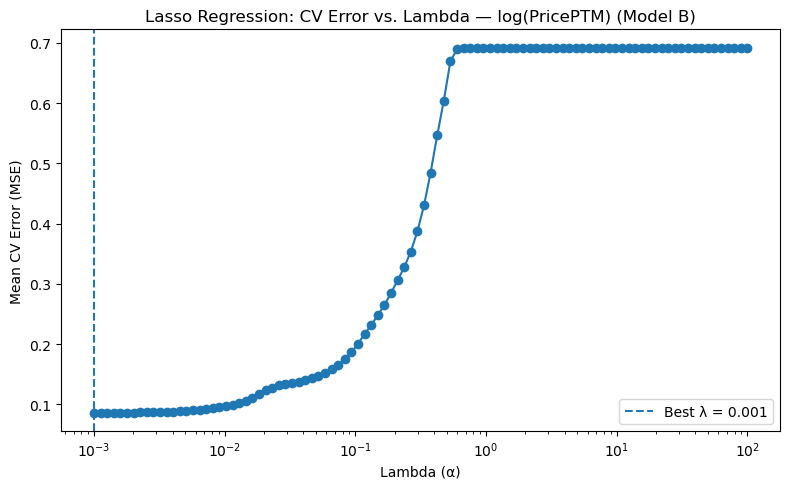

            Variable  Coefficient
0           Distance    -1.140865
4        Distance_sq     0.735129
3          Dereg_Yes    -0.454811
1             Weight    -0.371334
6   Dereg_x_Distance    -0.030808
2       Origin_Miami     0.023754
5  Weight_x_Distance     0.007085


In [13]:
## Lasso Regression with Cross-Validation (using GridSearchCV) — Trucking Dataset (Model B)

# 1) Standardize predictors
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 2) Alpha grid (Lasso is sensitive to alpha)
alphas = np.logspace(-3, 2, 100)  # 0.001 → 100

# 3) 5-fold cross-validation setup
cv = KFold(n_splits=5, shuffle=True, random_state=42)

# 4) GridSearchCV over alphas (increase max_iter for convergence)
gs_lasso = GridSearchCV(
    estimator=Lasso(max_iter=10000),
    param_grid={"alpha": alphas},
    scoring="neg_mean_squared_error",
    cv=cv,
    return_train_score=True,
)

# 5) Fit the grid search on standardized predictors
gs_lasso.fit(X_scaled, y)

# 6) Best alpha (lambda)
best_alpha_lasso = gs_lasso.best_params_["alpha"]
print(f"Best lambda (alpha) for Lasso: {best_alpha_lasso:.4f}")

# 7) CV curve
mean_cv_mse_lasso = -gs_lasso.cv_results_["mean_test_score"]  # convert from negative MSE

plt.figure(figsize=(8,5))
plt.semilogx(alphas, mean_cv_mse_lasso, marker="o")
plt.axvline(best_alpha_lasso, linestyle="--", label=f"Best λ = {best_alpha_lasso:.3f}")
plt.xlabel("Lambda (α)")
plt.ylabel("Mean CV Error (MSE)")
plt.title("Lasso Regression: CV Error vs. Lambda — log(PricePTM) (Model B)")
plt.legend()
plt.tight_layout()
plt.show()

# 8) Inspect selected features at the best alpha
best_lasso = gs_lasso.best_estimator_
all_coefs = pd.Series(best_lasso.coef_, index=X.columns)

# Put into a tidy table and sort by absolute magnitude
all_coefs_df = all_coefs.reset_index()
all_coefs_df.columns = ["Variable", "Coefficient"]
all_coefs_df = all_coefs_df.reindex(all_coefs_df["Coefficient"].abs().sort_values(ascending=False).index)

print(all_coefs_df)

## Interpreting Lasso CV Results

Lasso regression with cross-validation selected a very small penalty (λ = 0.001), indicating that most predictors contribute meaningful information to predicting **log(Price per Ton-Mile)**.

### Coefficients (in order of importance)
| Variable | Coefficient | Interpretation |
|-----------|--------------|----------------|
| **Distance** | −1.14 | Longer hauls strongly reduce price per ton-mile, reflecting economies of distance. |
| **Distance²** | +0.74 | Positive curvature term — shows that cost reductions taper off at very long distances (the rate of decline flattens). |
| **Dereg_Yes** | −0.45 | Deregulation lowered rates overall, consistent with textbook findings. |
| **Weight** | −0.37 | Heavier loads cost less per ton-mile — bulk shipments are more efficient. |
| **Dereg × Distance** | −0.03 | Slight additional drop in price for longer hauls after deregulation, though effect is small. |
| **Origin_Miami** | +0.02 | Miami shipments are modestly more expensive than Jacksonville shipments. |
| **Weight × Distance** | +0.007 | Essentially zero — no strong joint effect between shipment size and distance. |



## Model B

The results of our Lasso regression suggest that we can drop the predictor `Weight × Distance` as its coefficient is essentially zero. Thus, we define **Model B** as

**Model B:** (`Distance`, `Weight`, `Dereg`, and `Origin`) + (`Distance²` and `Dereg × Distance`)

**In the code cell below,** write code to perform 5-fold CV on Model B using standard OLS and evaluate its predictive performance. Please call the *feature matrix* `X_modelB`.

The output from my solution is below (make sure it matches excatly before going on):
<code>
Cross-validation R^2 scores: [0.84035431 0.90828651 0.92029931 0.78114548 0.83419264]
Mean R^2: 0.8568556502275305
Standard deviation: 0.05135789626905348
</code>


In [14]:
X_modelB = pd.DataFrame({
    "Distance": X["Distance"],
    "Weight": X["Weight"],
    "Dereg_Yes": X["Dereg_Yes"],
    "Origin": X["Origin_Miami"],
    "Distance_sq": X["Distance_sq"],
    "Dereg_x_Distance": X["Dereg_x_Distance"]
})


ols = LinearRegression()
kf = KFold(n_splits=5, shuffle=True, random_state=42)


cv_scores = cross_val_score(model, X_modelB, y, cv=kf, scoring='r2')

print("Cross-validation R^2 scores:", cv_scores)
print("Mean R^2:", np.mean(cv_scores))
print("Standard deviation:", np.std(cv_scores))

Cross-validation R^2 scores: [0.84035431 0.90828651 0.92029931 0.78114548 0.83419264]
Mean R^2: 0.8568556502275305
Standard deviation: 0.05135789626905337


<div class="exercise"><b>Exercise 5: Interpreting the Cross-Validation Results</b></div>

In the markdown cell below, answer the following multiple choice questions—no explanations are necessary.  

1. Based on the 5-fold cross-validation results for **Model B** ($\text{Mean } R^2 = 0.857, \text{ SD } = 0.051 $) compared to **Model A** ($\text{Mean } R^2 = 0.795, \text{ SD } = 0.072$), which statement best describes their relative performance?  
   - A) Model B performs substantially worse than Model A across all folds.  
   - B) Model B performs slightly better than Model A on average, showing higher $R^2$ scores and more consistent results across folds.  
   - C) Model B greatly outperforms Model A and shows no signs of variability.  
   - D) Model B has a lower average $R^2$ but smaller variation across folds.  

---

2. What do these results suggest about the inclusion of the nonlinear and interaction terms in Model B?  
   - A) They slightly improve predictive performance and stability, indicating that curvature and policy interaction effects help explain variation in cost.  
   - B) They overfit the model, resulting in unstable predictions.  
   - C) They have no measurable effect on model performance.  
   - D) They reduce interpretability without improving predictive accuracy.  


1.B 
2.A

<div class="exercise"><b>Exercise 6: Extending Model B with Additional Interaction Effects</b></div>

**Model B** includes the core predictors — `Distance`, `Weight`, `Dereg`, and `Origin` — along with two additional terms: `Distance²` and `Dereg × Distance`.  These features allow for curvature and one key interaction, but other economically meaningful relationships may still exist.

To explore these, we will now add two more interaction terms that connect **distance** with other major cost drivers:

- **`Origin × Distance`** — the relationship between distance and cost may differ by region or market.  
- **`Weight × Distance`** — heavier shipments might benefit from stronger economies of scale over longer hauls.

By adding these terms, we let the model capture a richer structure in how distance interacts with origin, shipment size, and regulatory status. We’ll again use **Lasso regression with cross-validation** to decide which of these new effects truly improve predictive performance.

**In the next code cell, you will:**
1. Create a new feature matrix that includes these additional interaction terms.  
2. Perform **Lasso regression with cross-validation** to find the optimal penalty parameter (λ).  
3. Examine which coefficients remain nonzero to interpret which effects matter most.

<span style="color:red"><b>In the code cell below, write code to accomplish this task. Your graph and coefficients should match that below.</b></span>

<p align="center"><b>Figure 3: Lasso Regression: CV Error vs. Lambda — log(PricePTM)</b></p>

<p align="center">
  <img src="hw10Data/Fig3.png" alt="Figure 2: Lasso Regression: CV Error vs. Lambda — log(PricePTM)" width="700"/>
</p>

Best lambda (alpha) for Lasso: 0.0010


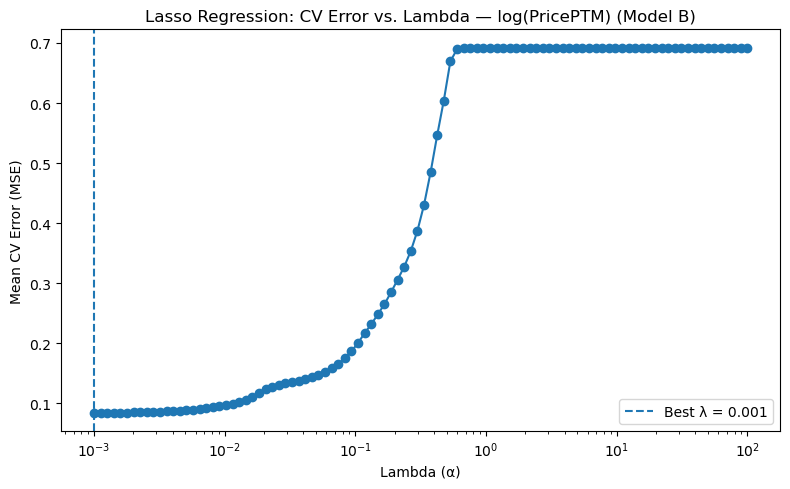

            Variable  Coefficient
0           Distance    -1.023345
4        Distance_sq     0.763650
3          Dereg_Yes    -0.458360
1             Weight    -0.369750
7  Origin_x_Distance    -0.218445
2       Origin_Miami     0.162334
6   Dereg_x_Distance    -0.023726
5  Weight_x_Distance     0.006626


In [15]:
X["Weight_x_Distance"] = X["Weight"] * X["Distance"]
X["Origin_x_Distance"] = X["Origin_Miami"] * X["Distance"]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

alphas = np.logspace(-3, 2, 100)  

cv = KFold(n_splits=5, shuffle=True, random_state=42)

gs_lasso = GridSearchCV(
    estimator=Lasso(max_iter=10000),
    param_grid={"alpha": alphas},
    scoring="neg_mean_squared_error",
    cv=cv,
    return_train_score=True,
)

gs_lasso.fit(X_scaled, y)

best_alpha_lasso = gs_lasso.best_params_["alpha"]
print(f"Best lambda (alpha) for Lasso: {best_alpha_lasso:.4f}")

mean_cv_mse_lasso = -gs_lasso.cv_results_["mean_test_score"]  

plt.figure(figsize=(8,5))
plt.semilogx(alphas, mean_cv_mse_lasso, marker="o")
plt.axvline(best_alpha_lasso, linestyle="--", label=f"Best λ = {best_alpha_lasso:.3f}")
plt.xlabel("Lambda (α)")
plt.ylabel("Mean CV Error (MSE)")
plt.title("Lasso Regression: CV Error vs. Lambda — log(PricePTM) (Model B)")
plt.legend()
plt.tight_layout()
plt.show()

best_lasso = gs_lasso.best_estimator_
all_coefs = pd.Series(best_lasso.coef_, index=X.columns)

all_coefs_df = all_coefs.reset_index()
all_coefs_df.columns = ["Variable", "Coefficient"]
all_coefs_df = all_coefs_df.reindex(all_coefs_df["Coefficient"].abs().sort_values(ascending=False).index)

print(all_coefs_df)

<div class="exercise"><b>Exercise 7: Model C</b></div>

The results of our Lasso regression suggest that we can drop the predictors `Weight_x_Distance` and `Dereg × Distance` as their coefficients are essentially zero.  Thus, we define **Model C** as

**Model C:** (`Distance`, `Weight`, `Dereg`, and `Origin`) + (`Distance²`, `Origin × Distance`)

This version keeps the most meaningful nonlinear and interaction terms while removing effects that do not materially improve predictive performance.  

**In the code cell below,** write code to perform **5-fold cross-validation (CV)** on **Model C** using **standard linear regression (OLS)** and evaluate its predictive performance.  
Please call the *feature matrix* `X_modelC`.

The output from my solution is below (make sure it matches exactly before going on):
```python
CCross-validation R^2 scores: [0.85234203 0.91297635 0.91555458 0.78018148 0.8454516 ]
Mean R^2: 0.8613012068627395
Standard deviation: 0.05005124499173294

In [16]:
X_modelC = pd.DataFrame({
    "Distance": X["Distance"],
    "Weight": X["Weight"],
    "Dereg_Yes": X["Dereg_Yes"],
    "Origin": X["Origin_Miami"],
    "Distance_sq": X["Distance_sq"],
    "Origin_x_Distance": X["Origin_x_Distance"]
})


ols = LinearRegression()
kf = KFold(n_splits=5, shuffle=True, random_state=42)

cv_scores = cross_val_score(model, X_modelC, y, cv=kf, scoring='r2')

print("Cross-validation R^2 scores:", cv_scores)
print("Mean R^2:", np.mean(cv_scores))
print("Standard deviation:", np.std(cv_scores))

Cross-validation R^2 scores: [0.85234203 0.91297635 0.91555458 0.78018148 0.8454516 ]
Mean R^2: 0.8613012068627395
Standard deviation: 0.05005124499173267


### Comparing Model Performance with Cross-Validation

Assuming you have correctly defined the feature matrices **`X_modelA`**, **`X_modelB`**, and **`X_modelC`**,  the code cell below will run **5-fold cross-validation** for each model and create a table showing the **mean $R^2$** and **standard deviation** across folds.

**Run the code cell below and make sure you table matches the output below or go back and try to find your mistake!**
```python
  Model  Mean R²  Std. Dev.
Model A 0.794506   0.071517
Model B 0.856856   0.051358
Model C 0.861301   0.050051

In [17]:
# Define cross-validation setup
kf = KFold(n_splits=5, shuffle=True, random_state=42)
model = LinearRegression()

# Dictionary of feature matrices
models = {
    "Model A": X_modelA,
    "Model B": X_modelB,
    "Model C": X_modelC,
}

# Store results
results = []

for name, X in models.items():
    cv_scores = cross_val_score(model, X, y, cv=kf, scoring='r2')
    results.append({
        "Model": name,
        "Mean R²": np.mean(cv_scores),
        "Std. Dev.": np.std(cv_scores)
    })

# Convert to DataFrame for easy display
cv_results_df = pd.DataFrame(results)

# Display results
print(cv_results_df.to_string(index=False))

  Model  Mean R²  Std. Dev.
Model A 0.794506   0.071517
Model B 0.856856   0.051358
Model C 0.861301   0.050051


<div class="exercise"><b>Exercise 8: Fitting the Final Model</b></div>

Based on the cross-validation results, **Model C** achieves the highest average $R^2$ and the most stable performance across folds.  Therefore, **Model C** is our chosen model for making predictions.

In the code cell below, **retrain Model C using all available data** so that it can be used to generate predictions on new observations.  
Be sure to fit the model using the complete feature matrix `X_modelC` and the response variable `y`. Then, print the $R^2$ value and RMSE, and finally the coefficients in order of magnitude.  Here is my solution (if you can't get them in order of magnitude, at least make sure the coefficients match):
```python
R^2:  0.8925576478424434
RMSE: 0.2686719133534986

Coefficients (by |magnitude|):

Intercept: 12.55798165272531
Dereg_Yes: -0.956180
Distance: -0.675654
Origin_Miami: 0.364647
Origin_x_Distance: -0.120539
Distance_sq: 0.077976
Weight: -0.041474


In [18]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np
import pandas as pd

final_model = LinearRegression()
final_model.fit(X_modelC, y)

y_pred = final_model.predict(X_modelC)

r2 = r2_score(y, y_pred)
rmse = np.sqrt(mean_squared_error(y, y_pred))

print(f"R^2: {r2}") 
print(f"RMSE: {rmse}\n")
print("Coefficients (sorted by |magnitude|):")
coefs = pd.Series(final_model.coef_, index=X_modelC.columns)
coefs_sorted = coefs.reindex(coefs.abs().sort_values(ascending=False).index)

print(f"Intercept: {final_model.intercept_:.6f}")

for name, coef in coefs_sorted.items():
    print(f"{name}: {coef:.6f}")

R^2: 0.8925576478424433
RMSE: 0.2686719133534987

Coefficients (sorted by |magnitude|):
Intercept: 12.557982
Dereg_Yes: -0.956180
Distance: -0.675654
Origin: 0.364647
Origin_x_Distance: -0.120539
Distance_sq: 0.077976
Weight: -0.041474


<div class="exercise"><b>Exercise 9: Interpreting the Coefficients of Model C</b></div>

In the markdown cell below, answer the following multiple choice questions--no explanations are necessary.

1. How should we interpret the coefficient for `Distance` (≈ −0.68) in the context of predicting `log(PricePTM)`?  
   - A) As distance increases, the price per ton-mile tends to decrease, holding other factors constant.  
   - B) As distance increases, the price per ton-mile tends to increase, holding other factors constant.  
   - C) Distance has no measurable effect on price per ton-mile.  
   - D) The effect of distance cannot be interpreted because it interacts with deregulation.

---

2. What does the negative coefficient for `Dereg_Yes` (≈ −0.96) suggest about deregulated shipments?  
   - A) Deregulated shipments are associated with a higher price per ton-mile, controlling for other factors.  
   - B) Deregulated shipments are associated with a lower price per ton-mile, controlling for other factors.  
   - C) Deregulation has no effect on shipping prices once distance is included.  
   - D) Deregulation only affects the variance, not the mean, of shipping prices.

---

3. How should we interpret the positive coefficient for `Origin_Miami` (≈ +0.36)?  
   - A) Shipments originating in Miami are predicted to have higher prices per ton-mile than those from the baseline origin, holding other variables constant.  
   - B) Shipments from Miami have lower prices per ton-mile than other origins, all else equal.  
   - C) The Miami variable captures distance rather than origin effects.  
   - D) The coefficient cannot be interpreted because `Origin` is categorical.


1A 
2B 
3A

## Predicting the Effect of Deregulation on Shipping Costs

We will now make **two predictions** to see how deregulation affects shipping prices.  To isolate the impact of deregulation, we’ll hold all other shipment characteristics constant and change only the `Dereg` variable.

Specifically:
- Both shipments have the **median** values of `Distance` and `Weight` from the dataset.
- The **origin** is set to `"Atlanta"`, which represents the **baseline (non-Miami)** category.
- The only difference is whether the shipment occurred **before** (`Dereg = "No"`) or **after** (`Dereg = "Yes"`) deregulation.

Because our model was trained using dummy-encoded variables and several derived features, we must:
1. Use `pd.get_dummies()` to encode `Origin` and `Dereg` exactly as in training.  
2. Add the two derived features from **Model C** — `Distance_sq` and `Origin_x_Distance`.  
3. Align all columns with those in `X_modelC` to ensure the feature names match the model’s training data.

Finally, we make predictions using our fitted model `final_model`.  The model predicts `log(PricePTM)` (the natural log of price per ton-mile), so we also exponentiate those predictions to return to the **original price scale**.

Run the code cell below to make the predictions and compare the expected shipping costs **before and after deregulation**.


In [19]:
# --- Define two scenarios in ORIGINAL variables (toggle deregulation only) ---
scenarios_raw = pd.DataFrame({
    "Distance": [np.median(trucking_df["Distance"])] * 2,
    "Weight":   [np.median(trucking_df["Weight"])] * 2,
    "Origin":   ["Atlanta", "Atlanta"],  # baseline (non-Miami) origin
    "Dereg":    ["No", "Yes"]            # regulated vs deregulated
})

# 1) One-hot encode to match training scheme
sc = pd.get_dummies(scenarios_raw, drop_first=True)
# After this, columns will include (if applicable): Distance, Weight, Origin_Miami, Dereg_Yes

# 2) Add ONLY Model C features
sc["Distance_sq"] = sc["Distance"] ** 2
sc["Origin_x_Distance"] = sc.get("Origin_Miami", 0) * sc["Distance"]

# 3) Align columns with X_modelC (missing cols -> 0, extra cols dropped)
sc = sc.reindex(columns=X_modelC.columns, fill_value=0)

# 4) Predict log and original scale using the trained final_model (fit on X_modelC)
sc["Predicted_log(PricePTM)"] = final_model.predict(sc)
sc["Predicted_PricePTM"] = np.exp(sc["Predicted_log(PricePTM)"])

print("Scenarios (original variables):")
print(scenarios_raw.to_string(index=False))

print("\nPredictions:")
print(sc[["Predicted_log(PricePTM)", "Predicted_PricePTM"]].to_string(index=False))

Scenarios (original variables):
 Distance  Weight  Origin Dereg
      3.0     7.5 Atlanta    No
      3.0     7.5 Atlanta   Yes

Predictions:
 Predicted_log(PricePTM)  Predicted_PricePTM
               10.921749        55367.560365
                9.965569        21280.988846


<div class="exercise"><b>Exercise 10: Interpreting the Effect of Deregulation</b></div>

In the markdown cell below, answer the following multiple choice question—no explanation is necessary.

1. Based on the model’s predictions, how did deregulation affect the predicted shipping cost per ton-mile for a typical shipment (3.0 tons over 7.5 miles from Atlanta)?  
   - A) Deregulation increased the expected price per ton-mile by about 60%.  
   - B) Deregulation had no measurable effect on shipping costs.  
   - C) Deregulation decreased the expected price per ton-mile by roughly 60%, holding other factors constant.  
   - D) Deregulation made prices more variable but did not change the average level.  


1 C